In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import os
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
os.makedirs('../report/images', exist_ok=True)
os.makedirs('../models', exist_ok=True)

from src.preprocessing import load_data, split_data, scale_features
from src.modeling import evaluate, save_model, build_results_table

In [2]:
train = load_data('../data/raw/train.csv')

X_train, X_val, X_test, y_train, y_val, y_test = split_data(train, val_size=0.1, test_size=0.1, seed=42)

print(f'train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}')
print(f'class ratio — train: {y_train.mean():.4f}, val: {y_val.mean():.4f}, test: {y_test.mean():.4f}')

train: (160000, 200), val: (20000, 200), test: (20000, 200)
class ratio — train: 0.1005, val: 0.1005, test: 0.1005


In [3]:
X_train_s, X_val_s, X_test_s, scaler = scale_features(X_train, X_val, X_test)

In [ ]:
feat_cols = [f'var_{i}' for i in range(200)]
os.makedirs('../data/processed', exist_ok=True)

pd.DataFrame(X_train[:1000], columns=feat_cols).assign(target=y_train[:1000]).to_csv('../data/processed/train_sample.csv', index=False)
pd.DataFrame(X_val,  columns=feat_cols).assign(target=y_val).to_csv('../data/processed/val.csv',  index=False)
pd.DataFrame(X_test, columns=feat_cols).assign(target=y_test).to_csv('../data/processed/test.csv', index=False)

print('сохранено в data/processed/')

In [4]:
dummy = DummyClassifier(strategy='stratified', random_state=42)
dummy.fit(X_train_s, y_train)

print('dummy val: ', evaluate(dummy, X_val_s, y_val))
print('dummy test:', evaluate(dummy, X_test_s, y_test))

dummy val:  {'roc_auc': 0.4964, 'avg_precision': 0.0999, 'f1': 0.0935, 'accuracy': 0.8187}
dummy test: {'roc_auc': 0.4986, 'avg_precision': 0.1003, 'f1': 0.0975, 'accuracy': 0.8196}


In [5]:
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
lr.fit(X_train_s, y_train)

lr_val  = evaluate(lr, X_val_s,  y_val)
lr_test = evaluate(lr, X_test_s, y_test)

print('LR val: ', lr_val)
print('LR test:', lr_test)

save_model(lr, '../models/logistic_regression.pkl')

LR val:  {'roc_auc': 0.8562, 'avg_precision': 0.5007, 'f1': 0.4181, 'accuracy': 0.7846}
LR test: {'roc_auc': 0.8548, 'avg_precision': 0.4896, 'f1': 0.412, 'accuracy': 0.7796}


In [6]:
idx_sub = np.random.choice(len(y_train), 30_000, replace=False)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_s[idx_sub], y_train[idx_sub])

knn_val  = evaluate(knn, X_val_s,  y_val)
knn_test = evaluate(knn, X_test_s, y_test)

print('KNN val: ', knn_val)
print('KNN test:', knn_test)

KNN val:  {'roc_auc': 0.5402, 'avg_precision': 0.1143, 'f1': 0.003, 'accuracy': 0.8995}
KNN test: {'roc_auc': 0.5374, 'avg_precision': 0.1127, 'f1': 0.003, 'accuracy': 0.8994}


In [7]:
dummy_val  = evaluate(dummy, X_val_s, y_val)
dummy_test = evaluate(dummy, X_test_s, y_test)

records = [
    {'model': 'Dummy',              'val_roc_auc': dummy_val['roc_auc'],  'val_avg_precision': dummy_val['avg_precision'],  'test_roc_auc': dummy_test['roc_auc']},
    {'model': 'Logistic Regression','val_roc_auc': lr_val['roc_auc'],     'val_avg_precision': lr_val['avg_precision'],     'test_roc_auc': lr_test['roc_auc']},
    {'model': 'KNN k=5',            'val_roc_auc': knn_val['roc_auc'],    'val_avg_precision': knn_val['avg_precision'],    'test_roc_auc': knn_test['roc_auc']},
]

build_results_table(records)

,model,val_roc_auc,val_avg_precision,test_roc_auc
0,Logistic Regression,0.8562,0.5007,0.8548
1,KNN k=5,0.5402,0.1143,0.5374
2,Dummy,0.4964,0.0999,0.4986


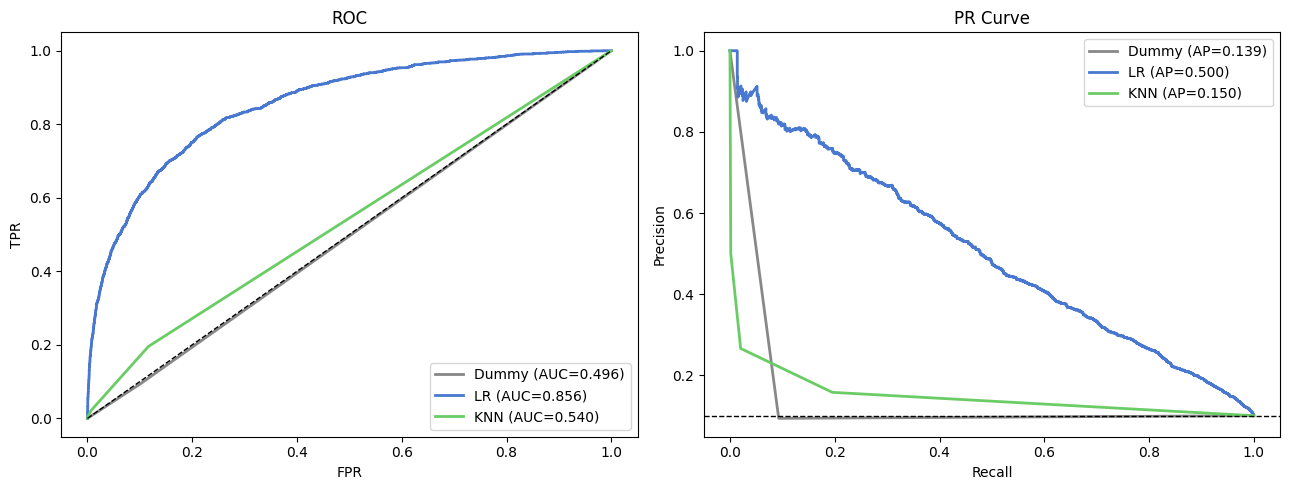

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, model, color in [('Dummy', dummy, '#888'), ('LR', lr, '#4878CF'), ('KNN', knn, '#6ACC65')]:
    p = model.predict_proba(X_val_s)[:, 1]

    fpr, tpr, _ = roc_curve(y_val, p)
    ax1.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc(fpr,tpr):.3f})')

    pr, rc, _ = precision_recall_curve(y_val, p)
    ax2.plot(rc, pr, color=color, lw=2, label=f'{name} (AP={auc(rc,pr):.3f})')

ax1.plot([0,1],[0,1],'k--',lw=1)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('ROC'); ax1.legend(loc='lower right')

ax2.axhline(y_val.mean(), color='k', ls='--', lw=1)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('PR Curve'); ax2.legend()

plt.tight_layout()
plt.savefig('../report/images/baseline_roc_pr.png', dpi=120, bbox_inches='tight')
plt.show()

Тут я понятно что Линейная регрессия самая лучшая и я взял ее за Baseline